# UAAL clinical landmark detection ? YOLO11
Train a bounding-box detector on the local UAAL clinical COCO annotations. Uses the supplied **2,683 training / 1,131 validation images**, preserving their split. Segmentation polygons are not used.

The JSON defines 10 classes: Right vocal fold, Left vocal fold, Glottic aperture, Glottis, Epiglottis, Right nostril, Left nostril, Nose, Trachea, Channel. **Trachea and Channel have zero annotations in both supplied splits**: this notebook retains their class IDs, but cannot learn or evaluate them. Add labeled examples before expecting those detections. Some other classes have very few training examples; inspect per-class results.

Run cells in order. Outputs stay under `Bronchoscopy/uaal_outputs`; source annotations and images are read only. Converted images are copied, requiring several GB of free disk space. The first model load downloads pretrained weights. Training is a research baseline, not a validated clinical navigation system.


## 1. Dependencies
Use your existing CUDA-enabled PyTorch environment. The inspected environment has PyTorch 2.11.0+cu128 and CUDA available. The installation cell supplies the other notebook dependencies; restart the kernel if requested. Package versions are recorded with each run.


In [1]:
%pip install "ultralytics>=8.3,<9" pandas matplotlib pillow pyyaml


   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.4 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 2.9 MB/s  0:00:00
   ---------------------------------------- 0.0/865.2 kB ? eta -:--:--
   ------------------------ --------------- 524.3/865.2 kB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 865.2/865.2 kB 3.5 MB/s  0:00:00
   ---------------------------------------- 0.0/53.7 MB ? eta -:--:--
    --------------------------------------- 0.8/53.7 MB 3.7 MB/s eta 0:00:15
   - -------------------------------------- 1.6/53.7 MB 3.8 MB/s eta 0:00:14
   - -------------------------------------- 2.1/53.7 MB 3.8 MB/s eta 0:00:14
   -- ------------------------------------- 2.9/53.7 MB 3.7 MB/s eta 0:00:14
   -- ------------------------------------- 3.7/53.7 MB 3.6 MB/s eta 0:00:14
   --- -----------------------

In [2]:
import json
import math
import random
import re
import shutil
import hashlib
import warnings
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime
import importlib.metadata

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import yaml
import torch
from IPython.display import display

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
DATA_ROOT = Path(r"C:\Users\Omen Max\Datasets\Bronchoscopic Datasets\UAAL\coco_ins_clinical\coco_ins_clinical")
HERE = Path.cwd().resolve()
PROJECT_DIR = HERE if HERE.name.lower() == "bronchoscopy" else HERE / "Bronchoscopy"
assert PROJECT_DIR.is_dir(), "Start the kernel from the repository root or Bronchoscopy folder."
OUTPUT_ROOT = PROJECT_DIR / "uaal_outputs"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("PyTorch:", torch.__version__, "Device:", DEVICE)
if DEVICE != "cpu":
    print(torch.cuda.get_device_name(0))
    # Test actual CUDA execution, not just device discovery.
    print("CUDA check:", (torch.ones(2, device="cuda") + 1).tolist())
else:
    warnings.warn("CUDA unavailable: full training on CPU will be slow.")


PyTorch: 2.11.0+cu128 Device: 0
NVIDIA GeForce RTX 5070 Ti Laptop GPU
CUDA check: [2.0, 2.0]


## 2. Inspect annotations and preserve the official split
Class IDs are explicitly mapped from COCO IDs to contiguous YOLO IDs; no COCO-80 mapping is used. Filename `AI...` tokens are checked for overlap as a **group proxy**, not proof of patient independence. Confirm their meaning against dataset metadata before making patient-level performance claims. No new random image split is made.


In [3]:
SPLITS = {"train": "train2017", "val": "val2017"}
coco = {}
for split, folder in SPLITS.items():
    annotation_path = DATA_ROOT / "annotations" / f"instances_{folder}.json"
    assert annotation_path.is_file(), annotation_path
    coco[split] = json.loads(annotation_path.read_text(encoding="utf-8"))

categories = sorted(coco["train"]["categories"], key=lambda x: x["id"])
assert len({c["id"] for c in categories}) == len(categories)
assert {c["id"]: c["name"] for c in categories} == {c["id"]: c["name"] for c in coco["val"]["categories"]}
cat_to_yolo = {c["id"]: i for i, c in enumerate(categories)}
names = {i: c["name"] for i, c in enumerate(categories)}
counts = {s: Counter(a["category_id"] for a in d["annotations"]) for s, d in coco.items()}
class_table = pd.DataFrame([
    {"yolo_id": i, "coco_id": c["id"], "class": c["name"],
     "train_boxes": counts["train"][c["id"]], "val_boxes": counts["val"][c["id"]]}
    for i, c in enumerate(categories)
])
display(class_table)
missing = class_table.loc[class_table.train_boxes == 0, "class"].tolist()
if missing:
    warnings.warn(f"No training examples for {missing}; these classes cannot be learned.")

groups = {}
for split, data in coco.items():
    ids = [im["id"] for im in data["images"]]
    assert len(ids) == len(set(ids)), f"Duplicate image IDs in {split}"
    image_ids = set(ids)
    assert all(a["image_id"] in image_ids and a["category_id"] in cat_to_yolo for a in data["annotations"])
    filenames = [im["file_name"] for im in data["images"]]
    assert len(filenames) == len(set(filenames)), f"Duplicate filenames in {split}"
    absent = [f for f in filenames if not (DATA_ROOT / SPLITS[split] / f).is_file()]
    assert not absent, f"Missing {len(absent)} images, e.g. {absent[:3]}"
    tokens = [re.search(r"AI\d+", f) for f in filenames]
    assert all(tokens), "Unknown filename convention; inspect grouping before training."
    groups[split] = {m.group() for m in tokens}
    print(split, len(ids), "images;", len(data["annotations"]), "boxes;", len(groups[split]), "filename groups")
assert not groups["train"] & groups["val"], "Filename group leakage across splits"
assert not ({i["file_name"] for i in coco["train"]["images"]} & {i["file_name"] for i in coco["val"]["images"]}), "Overlapping filenames"


,yolo_id,coco_id,class,train_boxes,val_boxes
0,0,1,Right vocal fold,1015,513
1,1,2,Left vocal fold,1043,532
2,2,3,Glottic aperture,1041,490
3,3,4,Glottis,1821,742
4,4,5,Epiglottis,2003,680
5,5,6,Right nostril,36,140
6,6,7,Left nostril,46,54
7,7,8,Nose,30,144
8,8,9,Trachea,0,0
9,9,10,Channel,0,0


train 2683 images; 7035 boxes; 9 filename groups
val 1131 images; 3295 boxes; 4 filename groups


C:\Users\Omen Max\AppData\Local\Temp\ipykernel_35640\3374355498.py:22: UserWarning: No training examples for ['Trachea', 'Channel']; these classes cannot be learned.
  warnings.warn(f"No training examples for {missing}; these classes cannot be learned.")


## 3. Convert COCO boxes to YOLO
Each row is `class_id center_x center_y width height`, normalized by image dimensions. Boxes are clipped to image boundaries; malformed/degenerate boxes stop conversion. Crowd annotations stop conversion to avoid silently treating ignored regions as background. Empty images receive empty label files.

The cache key includes annotation contents and source location. A fresh cache is built only when needed; image copies prevent training-time image repair from modifying originals. Delete the generated cache manually if source image bytes change without annotation changes.


In [4]:
def normalized_box(annotation, width, height):
    if annotation.get("iscrowd", 0):
        raise ValueError(f"Crowd annotation requires an explicit ignore policy: {annotation['id']}")
    x, y, w, h = map(float, annotation["bbox"])
    if not all(math.isfinite(v) for v in (x, y, w, h)) or w <= 0 or h <= 0:
        raise ValueError(f"Invalid bbox: {annotation['id']}")
    x1, y1 = max(0., x), max(0., y)
    x2, y2 = min(float(width), x + w), min(float(height), y + h)
    if x2 <= x1 or y2 <= y1:
        raise ValueError(f"Box outside image: {annotation['id']}")
    clipped = (x1 != x or y1 != y or x2 != x + w or y2 != y + h)
    return ((x1+x2)/(2*width), (y1+y2)/(2*height), (x2-x1)/width, (y2-y1)/height), clipped

fingerprint = hashlib.sha256(str(DATA_ROOT.resolve()).encode())
fingerprint.update(b"uaal-coco-boxes-v1")
for folder in SPLITS.values():
    fingerprint.update((DATA_ROOT / "annotations" / f"instances_{folder}.json").read_bytes())
YOLO_ROOT = OUTPUT_ROOT / f"dataset_{fingerprint.hexdigest()[:12]}"
DATA_YAML = YOLO_ROOT / "data.yaml"
marker = YOLO_ROOT / "conversion_complete.json"
conversion_stats = []
for split, folder in SPLITS.items():
    image_dir = YOLO_ROOT / "images" / split
    label_dir = YOLO_ROOT / "labels" / split
    image_dir.mkdir(parents=True, exist_ok=True)
    label_dir.mkdir(parents=True, exist_ok=True)
    by_image = defaultdict(list)
    for ann in coco[split]["annotations"]:
        by_image[ann["image_id"]].append(ann)
    n_boxes = n_clipped = n_empty = 0
    for record in coco[split]["images"]:
        source = (DATA_ROOT / folder / record["file_name"]).resolve()
        assert source.is_relative_to((DATA_ROOT / folder).resolve())
        # Unique IDs avoid basename collisions when filenames contain subfolders.
        stem = f"{record['id']:08d}"
        destination = image_dir / (stem + source.suffix.lower())
        with Image.open(source) as im:
            assert im.size == (record["width"], record["height"]), f"Dimension mismatch: {source}"
        assert record["width"] > 0 and record["height"] > 0
        lines = []
        for ann in by_image[record["id"]]:
            box, clipped = normalized_box(ann, record["width"], record["height"])
            assert all(0 <= v <= 1 for v in box)
            lines.append(str(cat_to_yolo[ann["category_id"]]) + " " + " ".join(f"{v:.8f}" for v in box))
            n_boxes += 1
            n_clipped += int(clipped)
        n_empty += int(not lines)
        if not marker.exists() or not destination.exists() or destination.stat().st_size != source.stat().st_size:
            shutil.copy2(source, destination)
        (label_dir / f"{stem}.txt").write_text("\n".join(lines) + ("\n" if lines else ""), encoding="utf-8")
    conversion_stats.append(dict(split=split, images=len(coco[split]["images"]), boxes=n_boxes, clipped=n_clipped, empty_images=n_empty))
DATA_YAML.write_text(yaml.safe_dump({"path": YOLO_ROOT.as_posix(), "train": "images/train", "val": "images/val", "names": names}, sort_keys=False), encoding="utf-8")
marker.write_text(json.dumps(conversion_stats, indent=2), encoding="utf-8")
class_table.to_csv(YOLO_ROOT / "class_counts.csv", index=False)
display(pd.DataFrame(conversion_stats))
print(DATA_YAML)


,split,images,boxes,clipped,empty_images
0,train,2683,7035,43,0
1,val,1131,3295,58,0


C:\Users\Omen Max\Marina\Nebras_RandD\Bronchoscopy\uaal_outputs\dataset_aa9443fa52d8\data.yaml


## 4. Check converted labels visually
Review these overlays before training. Colors correspond to YOLO class IDs.


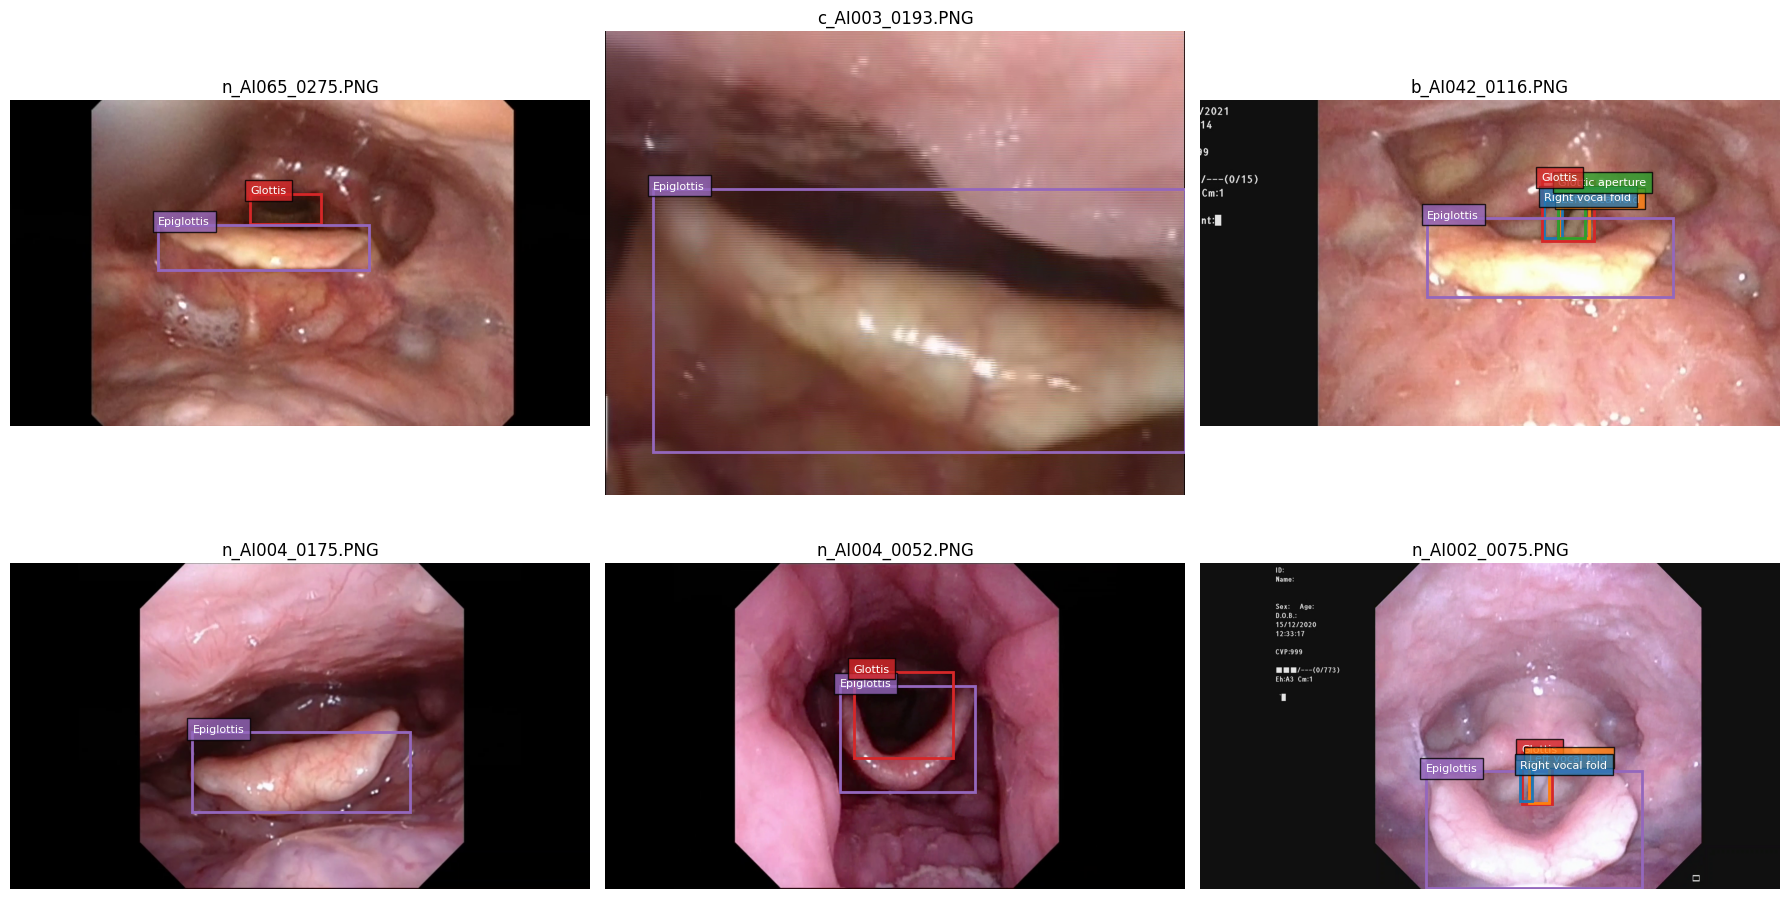

In [5]:
sample = random.Random(SEED).sample(coco["train"]["images"], min(6, len(coco["train"]["images"])))
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, record in zip(axes.flat, sample):
    path = YOLO_ROOT / "images/train" / (f"{record['id']:08d}" + Path(record["file_name"]).suffix.lower())
    with Image.open(path) as im:
        ax.imshow(im.convert("RGB"))
    w, h = record["width"], record["height"]
    label = YOLO_ROOT / "labels/train" / f"{record['id']:08d}.txt"
    for line in label.read_text().splitlines():
        cls, cx, cy, bw, bh = map(float, line.split())
        x, y = (cx-bw/2)*w, (cy-bh/2)*h
        color = plt.get_cmap("tab10")(int(cls))
        ax.add_patch(Rectangle((x,y), bw*w, bh*h, fill=False, edgecolor=color, linewidth=2))
        ax.text(x, y, names[int(cls)], color="white", fontsize=8, bbox={"facecolor":color,"alpha":0.8})
    ax.set_title(record["file_name"])
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()


## 5. Train
Default: pretrained YOLO11s, 100 epochs, 640-pixel input, batch 8, early stopping patience 20. Reduce `BATCH` if GPU memory is insufficient; use `yolo11n.pt` for a smaller baseline. `workers=0` supports Windows notebook execution. Flips are disabled to preserve left/right anatomy, with modest color and geometric augmentation and no mosaic/mixup.

Set `SMOKE_TEST=True` for a one-epoch pipeline check; switch it back to `False` for the full run. Every run uses a new output directory. For an interrupted run, set `RESUME_FROM` to its `weights/last.pt`; resume restores the prior training settings.


In [6]:
from ultralytics import YOLO

MODEL = "yolo11s.pt"
EPOCHS = 100
IMGSZ = 640
BATCH = 8
SMOKE_TEST = False
RESUME_FROM = None  # e.g. OUTPUT_ROOT / "runs" / "uaal_..." / "weights" / "last.pt"

if RESUME_FROM is not None:
    assert Path(RESUME_FROM).is_file(), RESUME_FROM
    model = YOLO(str(RESUME_FROM))
    train_results = model.train(resume=True, device=DEVICE, workers=0)
else:
    run_name = ("smoke_" if SMOKE_TEST else "uaal_") + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    model = YOLO(MODEL)
    train_results = model.train(
        data=str(DATA_YAML), epochs=1 if SMOKE_TEST else EPOCHS,
        fraction=0.05 if SMOKE_TEST else 1.0, imgsz=IMGSZ, batch=BATCH,
        device=DEVICE, workers=0, seed=SEED, deterministic=True,
        optimizer="AdamW", lr0=0.001, weight_decay=0.0005,
        patience=20, amp=DEVICE != "cpu", cache=False,
        fliplr=0.0, flipud=0.0, degrees=5.0, translate=0.05, scale=0.15,
        shear=0.0, perspective=0.0, mosaic=0.0, mixup=0.0,
        hsv_h=0.01, hsv_s=0.2, hsv_v=0.2,
        project=str(OUTPUT_ROOT / "runs"), name=run_name,
        save=True, plots=True, exist_ok=False,
    )
RUN_DIR = Path(model.trainer.save_dir)
BEST_WEIGHTS = RUN_DIR / "weights" / "best.pt"
assert BEST_WEIGHTS.is_file(), BEST_WEIGHTS
versions = {p: importlib.metadata.version(p) for p in ["torch", "torchvision", "ultralytics", "numpy", "pandas", "pillow"]}
(RUN_DIR / "environment.json").write_text(json.dumps(versions, indent=2), encoding="utf-8")
(RUN_DIR / "dataset_metadata.json").write_text(json.dumps({"source":str(DATA_ROOT), "fingerprint":fingerprint.hexdigest(), "missing_training_classes":missing, "filename_groups":{s:sorted(g) for s,g in groups.items()}}, indent=2), encoding="utf-8")
print("Best checkpoint:", BEST_WEIGHTS)


Creating new Ultralytics Settings v0.0.8 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Omen Max\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.142  Python-3.10.8 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Ti Laptop GPU, 12227MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Omen Max\Marina\Nebras_RandD\Bronchoscopy\uaal_outputs\dataset_aa9443fa52d8\data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.

c:\Users\Omen Max\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.00.0 ms, read: 2835.1276.9 MB/s, size: 833.4 KB)
val: Scanning C:\Users\Omen Max\Marina\Nebras_RandD\Bronchoscopy\uaal_outputs\dataset_aa9443fa52d8\labels\val... 1131 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1131/1131 558.9it/s 2.0s0.1s
val: New cache created: C:\Users\Omen Max\Marina\Nebras_RandD\Bronchoscopy\uaal_outputs\dataset_aa9443fa52d8\labels\val.cache
optimizer: AdamW(lr=0.001, momentum=0.937) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
Plotting labels to C:\Users\Omen Max\Marina\Nebras_RandD\Bronchoscopy\uaal_outputs\runs\uaal_20260906_131638_781902\labels.jpg... 
Using 2683 train, 1131 val images for fraction=1.0 at imgsz=640
Using 0 dataloader workers
Logging results to C:\User

## 6. Validation and learning curves
This is the same validation split used for checkpoint selection, **not an independent test set**. Unsupported classes are shown as NaN rather than assigned misleading per-class AP. The main mAP covers classes with validation ground truth. Obtain a separate patient-held-out test set for a final assessment.


Ultralytics 8.4.142  Python-3.10.8 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Ti Laptop GPU, 12227MiB)
YOLO11s summary (fused): 100 layers, 9,416,670 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 4266.3391.9 MB/s, size: 776.2 KB)
val: Scanning C:\Users\Omen Max\Marina\Nebras_RandD\Bronchoscopy\uaal_outputs\dataset_aa9443fa52d8\labels\val.cache... 1131 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1131/1131  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 142/142 4.8it/s 29.4s0.2s
                   all       1131       3295      0.764      0.732      0.763      0.458
      Right vocal fold        513        513      0.833      0.835      0.861      0.483
       Left vocal fold        532        532      0.833      0.827      0.854      0.459
      Glottic aperture        490        490      0.768      0.806      0.814      0.547
               Glottis        742        

,yolo_id,coco_id,class,train_boxes,val_boxes,precision,recall,AP50,AP50_95,status
0,0,1,Right vocal fold,1015,513,0.832771,0.834827,0.860732,0.483498,evaluated
1,1,2,Left vocal fold,1043,532,0.833333,0.827063,0.854037,0.459317,evaluated
2,2,3,Glottic aperture,1041,490,0.768057,0.806122,0.814269,0.546860,evaluated
3,3,4,Glottis,1821,742,0.884287,0.900270,0.931261,0.631660,evaluated
4,4,5,Epiglottis,2003,680,0.953754,0.839706,0.885139,0.682098,evaluated
5,5,6,Right nostril,36,140,0.765346,0.735714,0.741027,0.330700,evaluated
6,6,7,Left nostril,46,54,0.259108,0.168430,0.175434,0.045133,evaluated
7,7,8,Nose,30,144,0.815364,0.743056,0.844018,0.483735,evaluated
8,8,9,Trachea,0,0,NaN,NaN,NaN,NaN,no training examples
9,9,10,Channel,0,0,NaN,NaN,NaN,NaN,no training examples


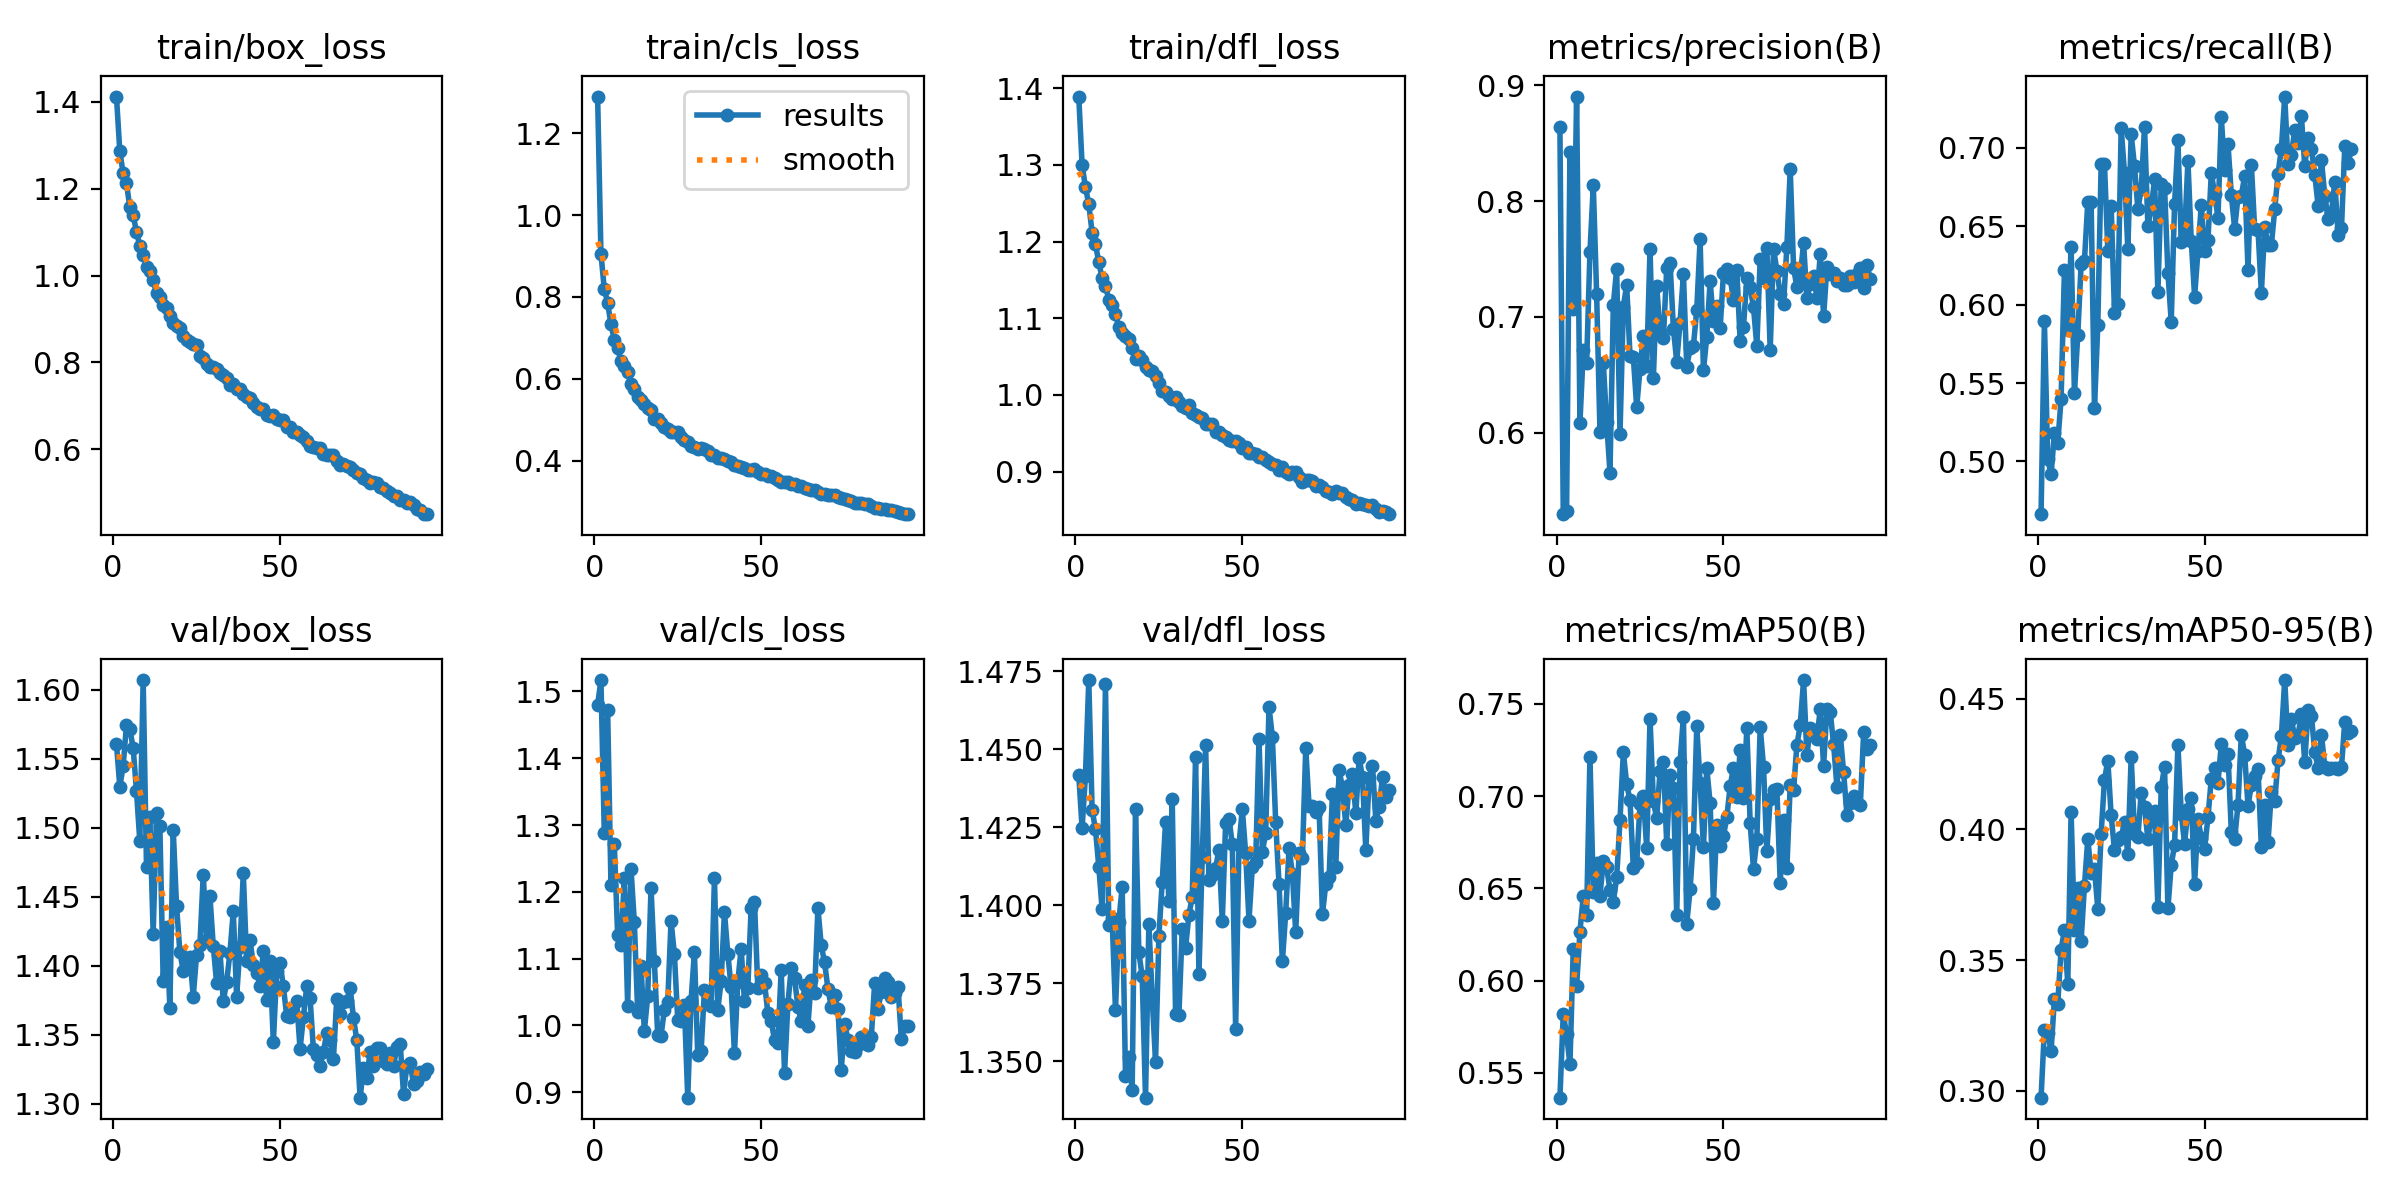

Validation plots: C:\Users\Omen Max\Marina\Nebras_RandD\Bronchoscopy\uaal_outputs\runs\uaal_20260906_131638_781902\validation


In [7]:
best = YOLO(str(BEST_WEIGHTS))
metrics = best.val(data=str(DATA_YAML), split="val", imgsz=IMGSZ, batch=BATCH,
                   device=DEVICE, workers=0, plots=True,
                   project=str(RUN_DIR), name="validation", exist_ok=False)
print("mAP50:", metrics.box.map50, "mAP50-95:", metrics.box.map)
per_class = class_table.copy()
for col in ["precision", "recall", "AP50", "AP50_95"]:
    per_class[col] = float("nan")
for index, class_id in enumerate(metrics.box.ap_class_index):
    p, r, ap50, ap = metrics.box.class_result(index)
    per_class.loc[per_class.yolo_id == int(class_id), ["precision", "recall", "AP50", "AP50_95"]] = [p, r, ap50, ap]
per_class["status"] = per_class.apply(lambda row: "no training examples" if row.train_boxes == 0 else ("no validation examples" if row.val_boxes == 0 else "evaluated"), axis=1)
display(per_class)
per_class.to_csv(RUN_DIR / "per_class_metrics.csv", index=False)
(RUN_DIR / "validation_metrics.json").write_text(json.dumps({k:float(v) for k,v in metrics.results_dict.items()}, indent=2), encoding="utf-8")
curves = RUN_DIR / "results.png"
if curves.exists():
    display(Image.open(curves))
print("Validation plots:", metrics.save_dir)


## 7. Preview vocal folds and glottis on validation images
The preview selects images **by their ground-truth labels**, rather than taking the first 20 filenames. It focuses on Right vocal fold, Left vocal fold, Glottic aperture, and Glottis, which are below the epiglottis. Trachea and Channel have no annotations in this dataset, and there is no supplied test split.

Each row compares the selected ground-truth boxes with model predictions. Epiglottis, nostril, and nose boxes are hidden in this focused preview; they may still be visible anatomically in the images. Full validation metrics in section 6 still cover all supported classes. This deliberately selected preview is not a representative performance sample.

Edit `FOCUS_CLASSES` and `N_PREVIEW` below. Set `SOURCE` to a local image/video to predict on your own data (ground truth is only shown for the selected validation images). No retraining is needed if `best` is already loaded.


Right vocal fold: 513 validation images
Left vocal fold: 532 validation images
Glottic aperture: 490 validation images
Glottis: 742 validation images

0: 640x640 1 Right vocal fold, 1 Left vocal fold, 1 Glottis, 15.2ms
1: 640x640 1 Left vocal fold, 1 Glottic aperture, 2 Glottiss, 15.2ms
2: 640x640 1 Right vocal fold, 1 Left vocal fold, 1 Glottic aperture, 1 Glottis, 15.2ms
3: 640x640 1 Right vocal fold, 1 Left vocal fold, 1 Glottis, 15.2ms
4: 640x640 1 Right vocal fold, 1 Left vocal fold, 1 Glottic aperture, 1 Glottis, 15.2ms
5: 640x640 1 Right vocal fold, 1 Left vocal fold, 1 Glottic aperture, 1 Glottis, 15.2ms
6: 640x640 1 Glottic aperture, 1 Glottis, 15.2ms
7: 640x640 1 Right vocal fold, 1 Left vocal fold, 1 Glottis, 15.2ms
8: 640x640 1 Right vocal fold, 1 Left vocal fold, 1 Glottis, 15.2ms
9: 640x640 1 Right vocal fold, 1 Left vocal fold, 1 Glottic aperture, 1 Glottis, 15.2ms
10: 640x640 1 Right vocal fold, 1 Left vocal fold, 1 Glottic aperture, 1 Glottis, 15.2ms
11: 640x640 1 Glot

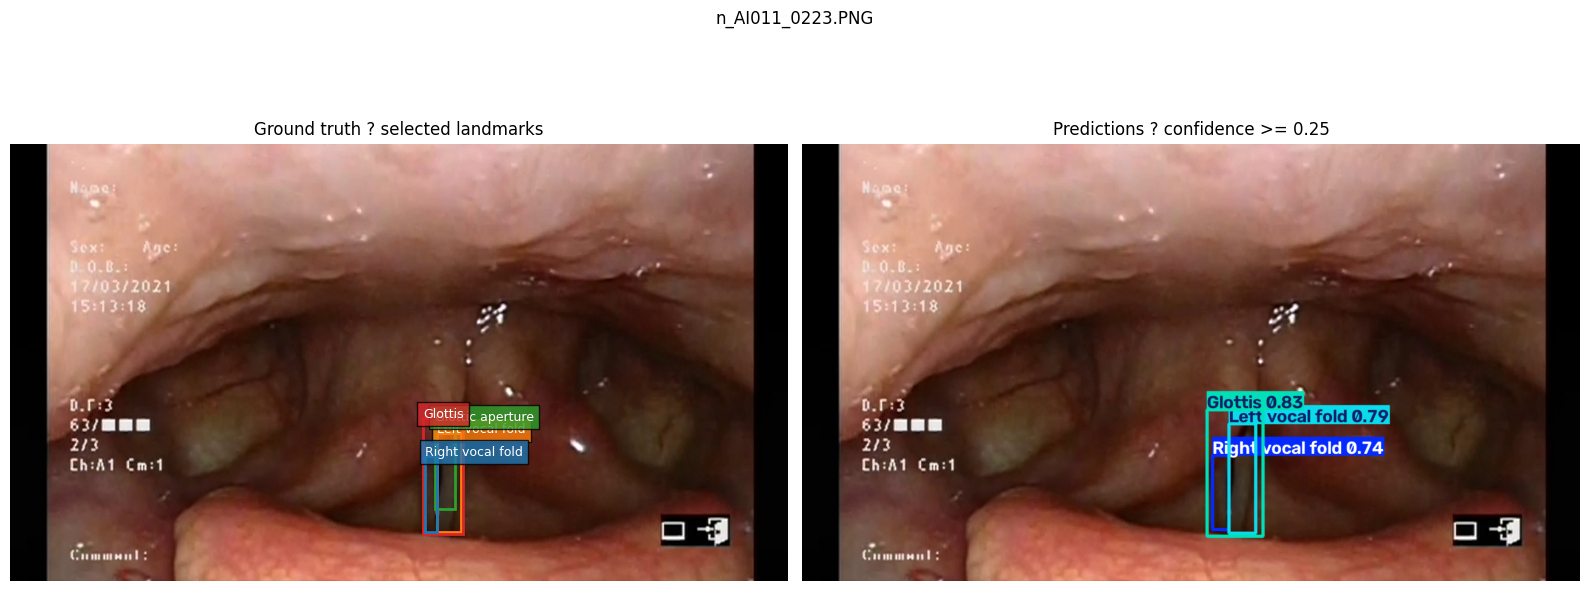

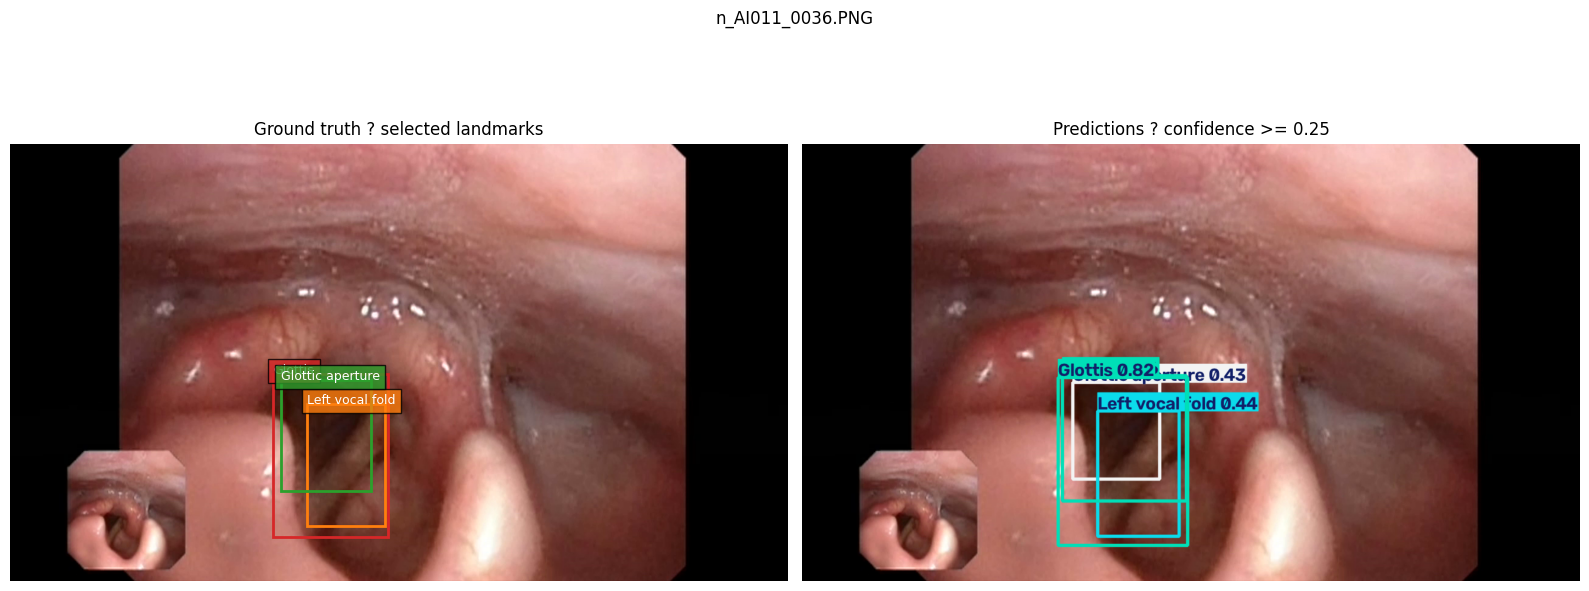

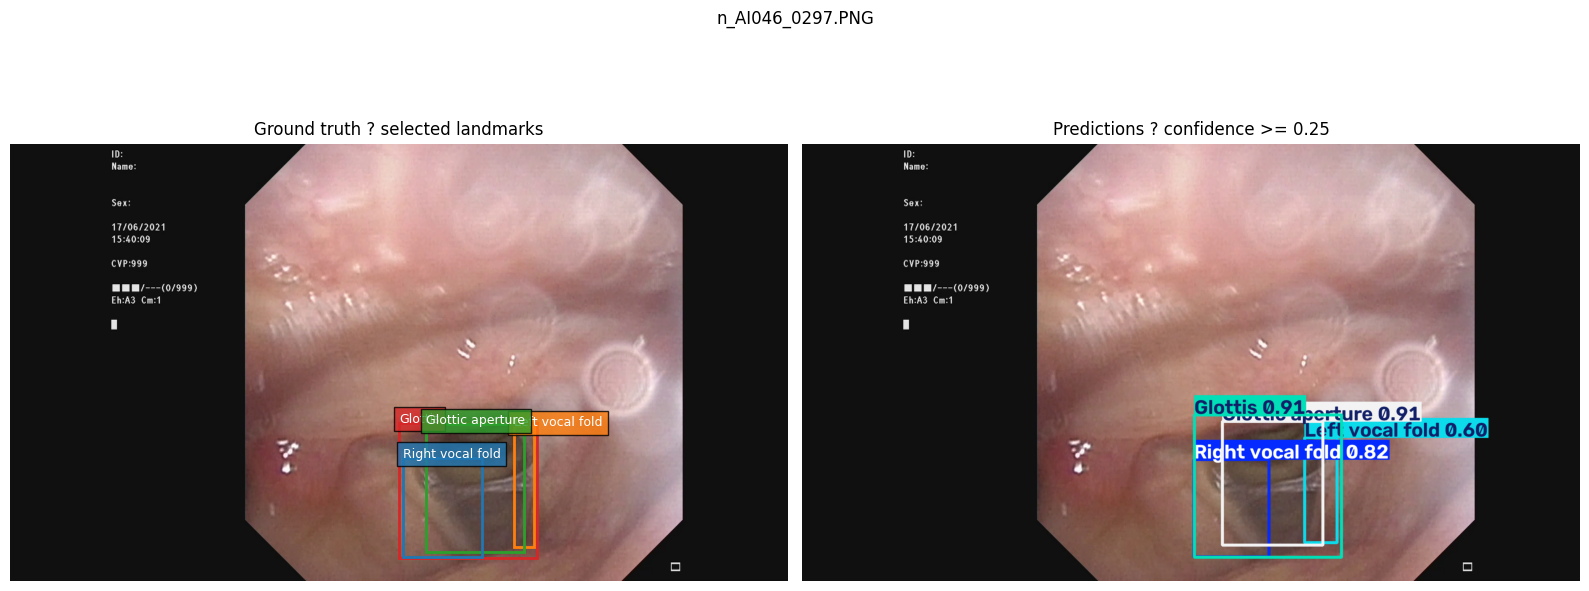

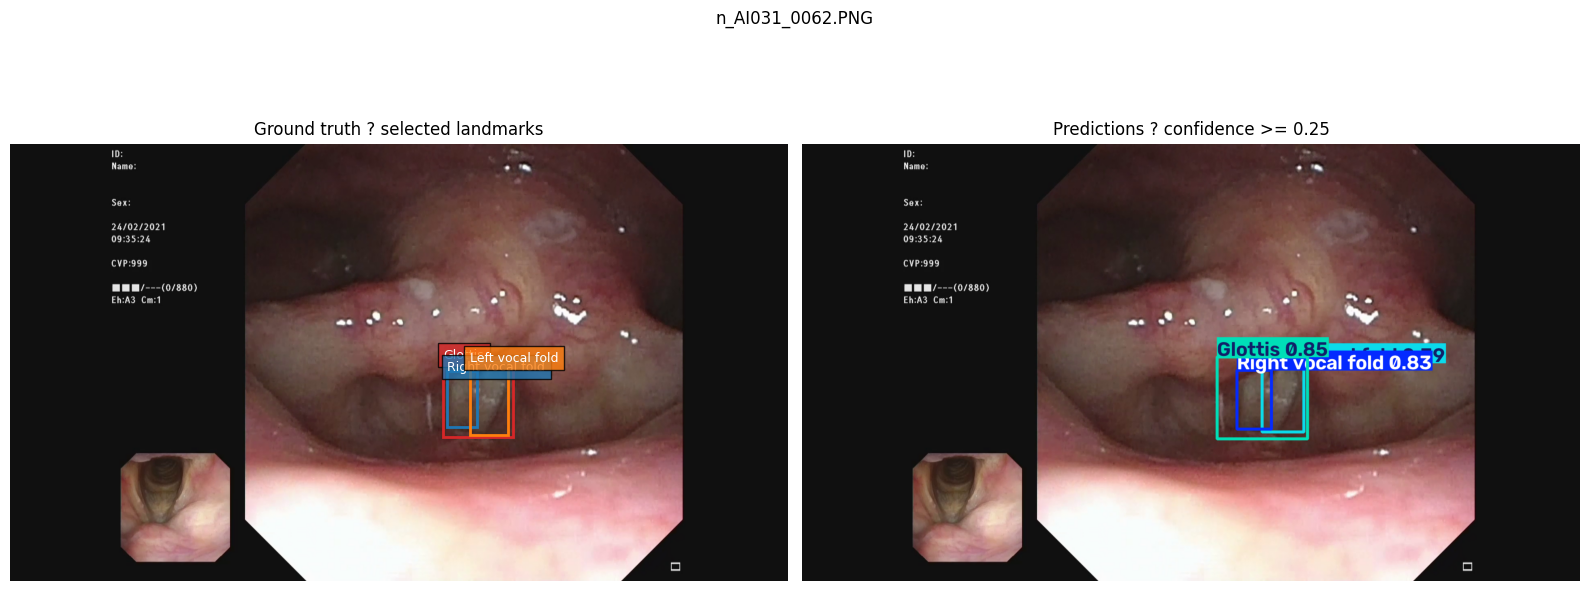

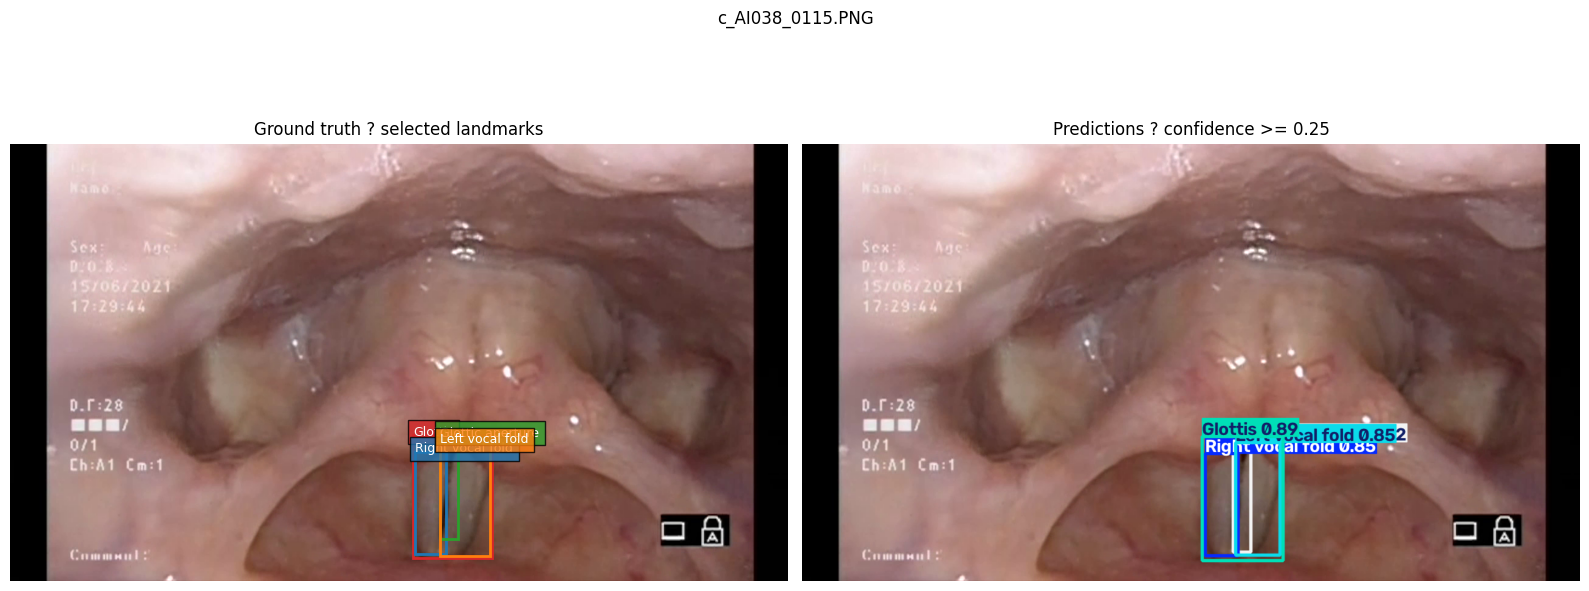

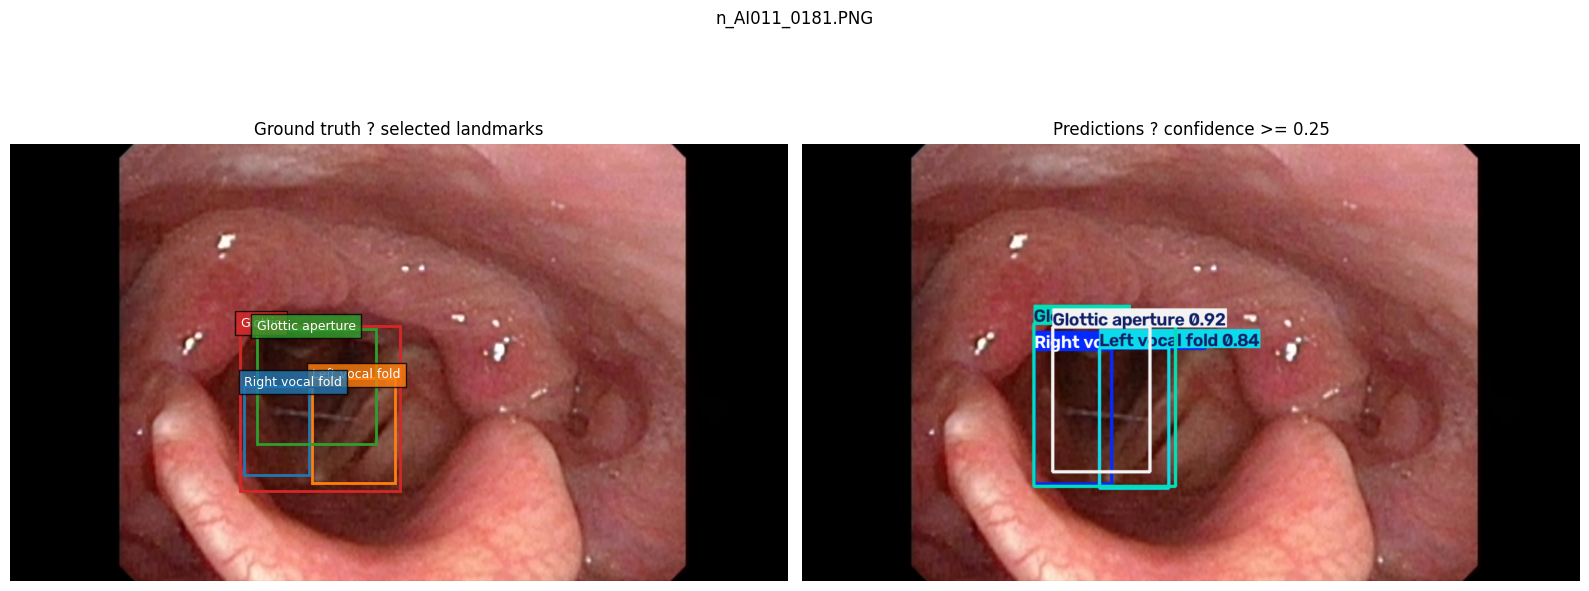

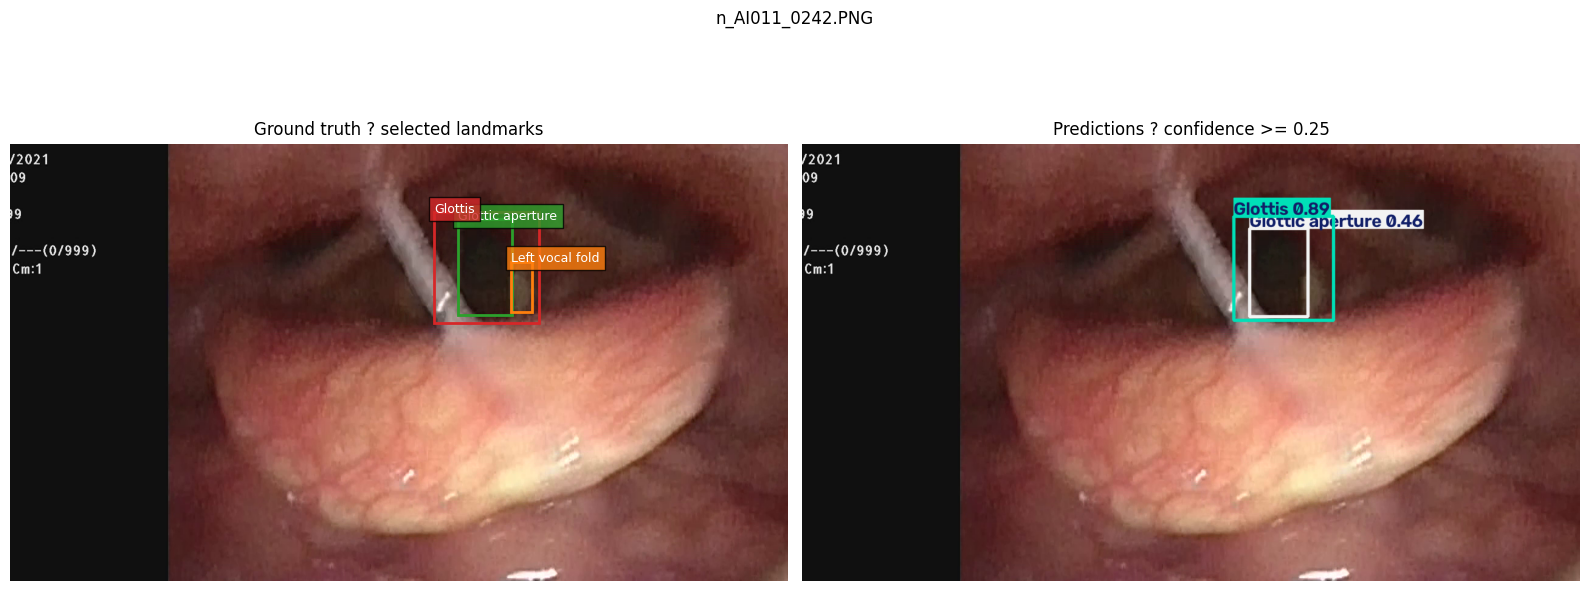

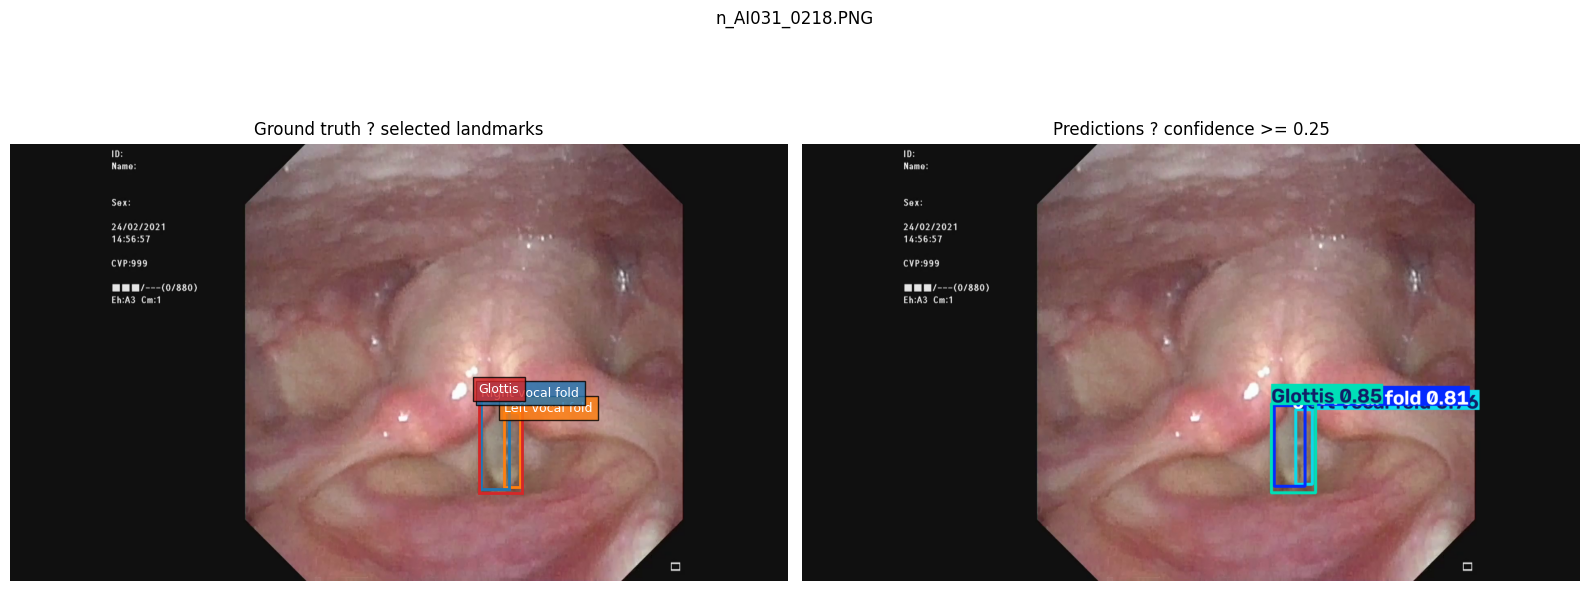

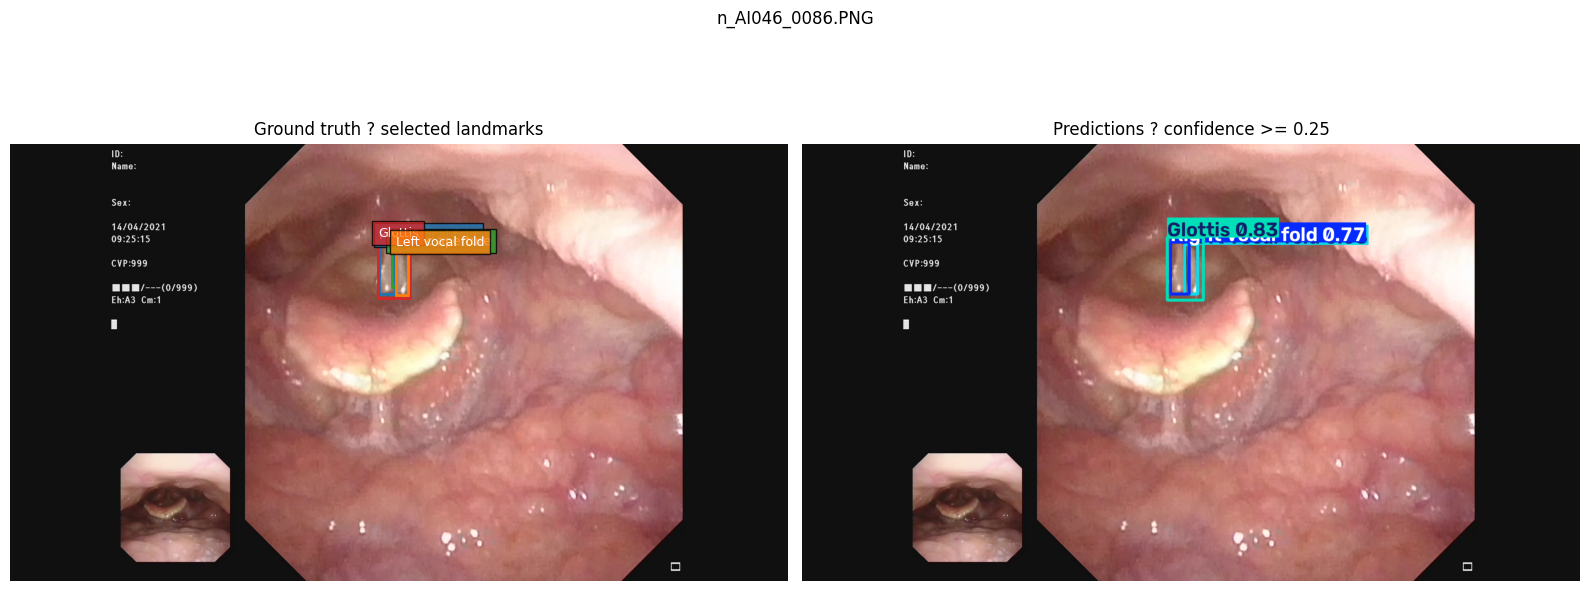

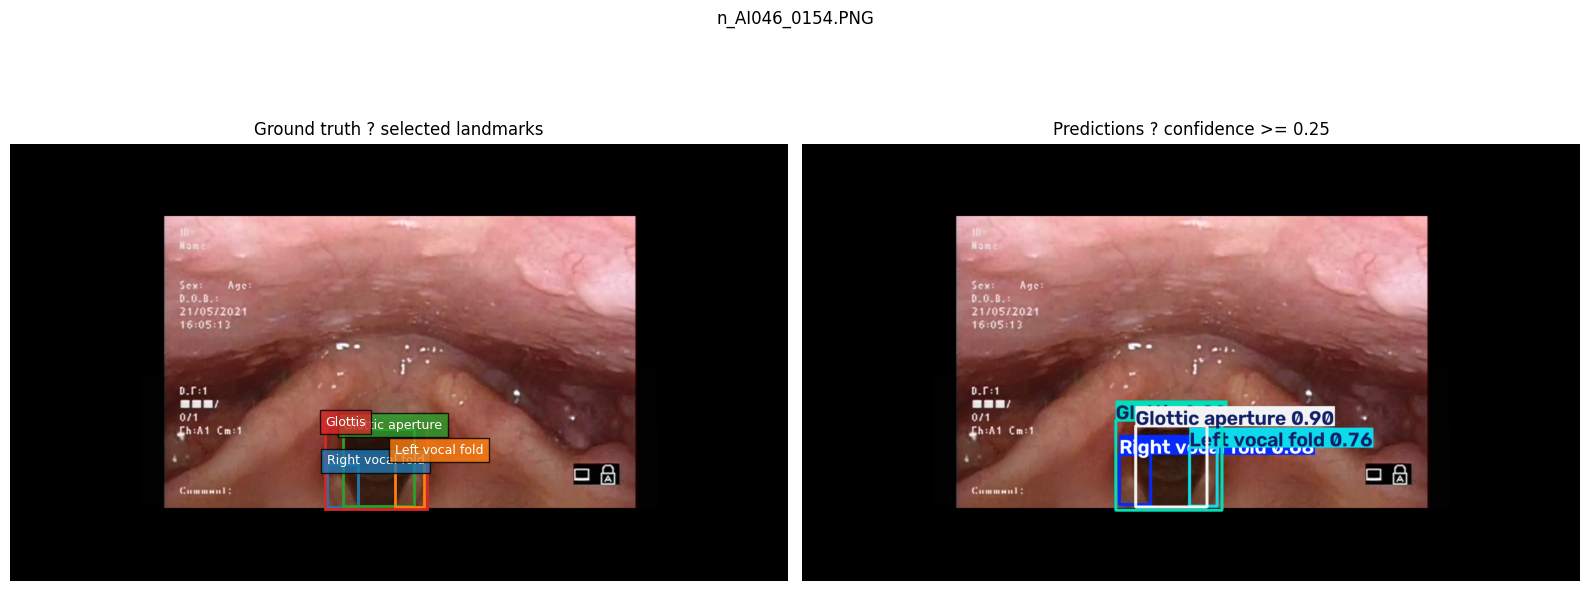

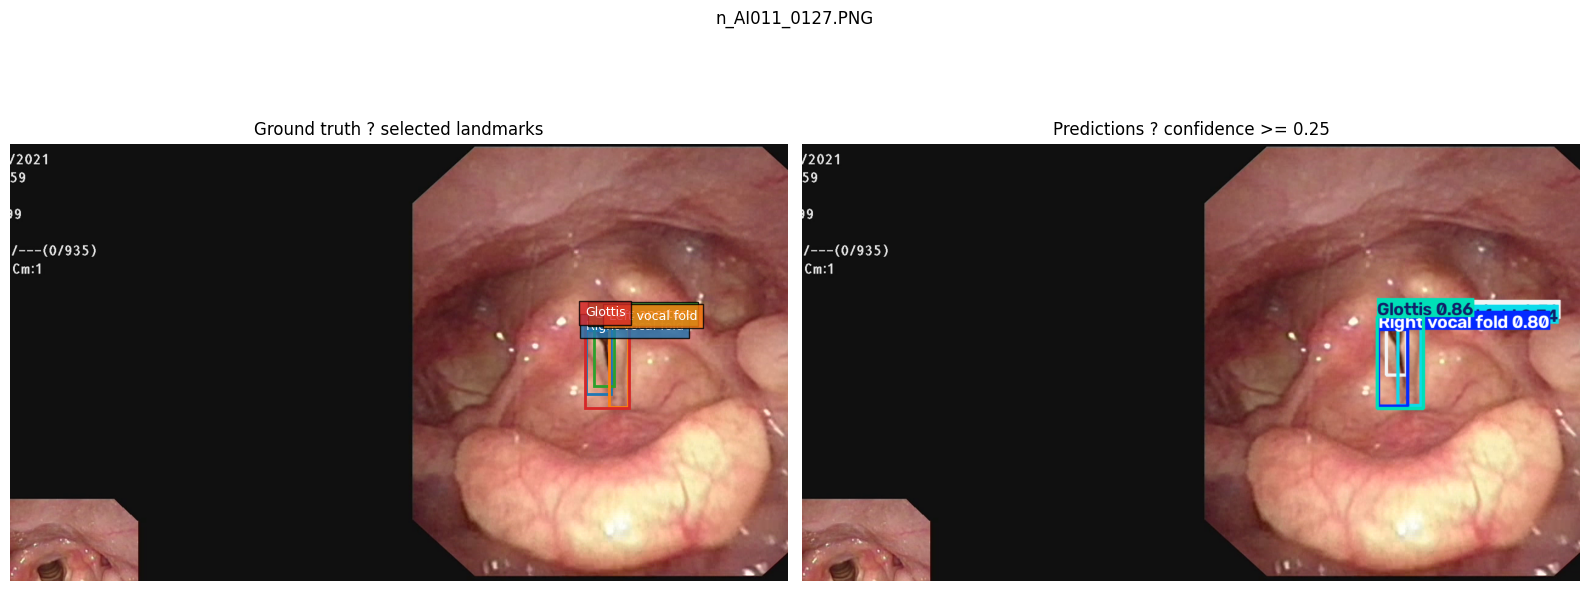

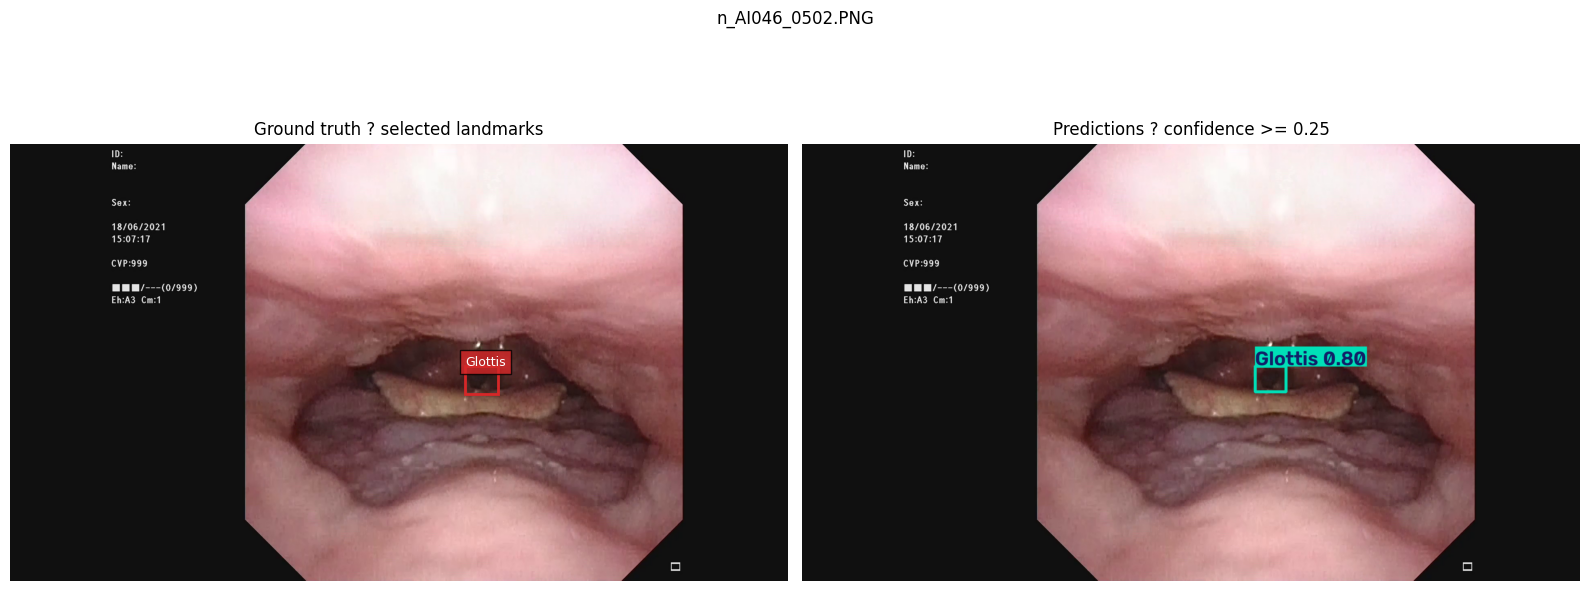

Run artifacts: C:\Users\Omen Max\Marina\Nebras_RandD\Bronchoscopy\uaal_outputs\runs\uaal_20260906_131638_781902


In [11]:
FOCUS_CLASSES = ["Right vocal fold", "Left vocal fold", "Glottic aperture", "Glottis"]
N_PREVIEW = 12
SOURCE = None  # None selects labeled validation images; alternatively Path(r"C:\path\image.jpg").
CONF = 0.25

unknown = set(FOCUS_CLASSES) - set(names.values())
assert not unknown, f"Unknown classes: {sorted(unknown)}"
assert FOCUS_CLASSES and N_PREVIEW > 0
focus_yolo_ids = [i for i, name in names.items() if name in FOCUS_CLASSES]
focus_coco_ids = {c["id"] for c in categories if c["name"] in FOCUS_CLASSES}
category_names = {c["id"]: c["name"] for c in categories}
val_annotations = defaultdict(list)
for annotation in coco["val"]["annotations"]:
    if annotation["category_id"] in focus_coco_ids:
        val_annotations[annotation["image_id"]].append(annotation)

selected_records = []
if SOURCE is None:
    # Round-robin class sampling gives rarer requested labels a chance to appear.
    rng = random.Random(SEED)
    pools = {}
    for category_id in sorted(focus_coco_ids):
        pool = [record for record in coco["val"]["images"]
                if any(a["category_id"] == category_id for a in val_annotations[record["id"]])]
        rng.shuffle(pool)
        pools[category_id] = pool
        print(f"{category_names[category_id]}: {len(pool)} validation images")
    selected_ids = set()
    while len(selected_records) < N_PREVIEW:
        added = False
        for pool in pools.values():
            while pool and pool[-1]["id"] in selected_ids:
                pool.pop()
            if pool and len(selected_records) < N_PREVIEW:
                record = pool.pop()
                selected_records.append(record)
                selected_ids.add(record["id"])
                added = True
        if not added:
            break
    assert selected_records, "No validation images contain the requested labels. Choose classes with validation annotations."
    inference_source = [str(YOLO_ROOT / "images" / "val" /
                           (f"{record['id']:08d}" + Path(record["file_name"]).suffix.lower()))
                        for record in selected_records]
else:
    source_path = Path(SOURCE)
    assert source_path.exists(), source_path
    if source_path.is_dir():
        inference_source = [str(path) for path in sorted(source_path.iterdir())
                            if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}][:N_PREVIEW]
        assert inference_source, "No supported images found in SOURCE."
    else:
        inference_source = str(source_path)

predictions = best.predict(source=inference_source, imgsz=IMGSZ, conf=CONF,
                           classes=focus_yolo_ids, device=DEVICE, agnostic_nms=False,
                           stream=True, save=True, project=str(RUN_DIR), name="focused_predictions")
try:
    for index, result in enumerate(predictions):
        if selected_records:
            record = selected_records[index]
            fig, axes = plt.subplots(1, 2, figsize=(16, 7))
            with Image.open(inference_source[index]) as image:
                axes[0].imshow(image.convert("RGB"))
            for annotation in val_annotations[record["id"]]:
                x, y, width, height = annotation["bbox"]
                color = plt.get_cmap("tab10")(cat_to_yolo[annotation["category_id"]])
                axes[0].add_patch(Rectangle((x, y), width, height, fill=False, edgecolor=color, linewidth=2))
                axes[0].text(x, y, category_names[annotation["category_id"]], color="white", fontsize=9,
                             bbox={"facecolor": color, "alpha": 0.8})
            axes[0].set_title("Ground truth ? selected landmarks")
            axes[1].imshow(result.plot()[..., ::-1])
            axes[1].set_title(f"Predictions ? confidence >= {CONF}" +
                              (" (none)" if len(result.boxes) == 0 else ""))
            for ax in axes:
                ax.axis("off")
            fig.suptitle(record["file_name"])
            plt.tight_layout()
            plt.show()
            plt.close(fig)
        else:
            display(Image.fromarray(result.plot()[..., ::-1]))
        if index + 1 >= N_PREVIEW:
            break
finally:
    predictions.close()
print("Run artifacts:", RUN_DIR)


## References
- [Ultralytics YOLO11 models](https://docs.ultralytics.com/models/yolo11/)
- [Detection dataset format](https://docs.ultralytics.com/datasets/detect/)
- [Training settings and resuming](https://docs.ultralytics.com/modes/train/)
- [Validation metrics](https://docs.ultralytics.com/modes/val/)

Dataset counts, class names and absence of Trachea/Channel examples above were read directly from the local COCO JSON files. No phantom data is included.
